In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent
from ant.centralised import P4

In [2]:
# Demo experiment
market_size = 150
seed = 25
G = nx.gnp_random_graph(market_size, 0.11, seed=seed)
# nx.draw(G)
# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
M1: Market = Market(market_size, graph=G, seed=seed, agent_type=GreedyAgent)
M2: Market = Market(market_size, graph=G, seed=seed, agent_type=ProportionalAgent)



# others
# M3: Market = Market(market_size, graph=G, seed=seed, agent_type=EqualDivisionAgent)
# M4: Market = Market(market_size, graph=G, seed=seed, agent_type=OptimalAgent)

M5: Market = Market(market_size, graph=G, seed=seed, agent_type=EgalitarianAgent)
M6: Market = Market(market_size, graph=G, seed=seed, agent_type=PettyAgent, delta=0.0)

In [15]:
mixed_agents = []

# First 50 agents are ImitationAgents
for i in range(0, 50):
    agent = ImitationAgent(id=i, seed=seed + i)
    mixed_agents.append(agent)

# Next 50 agents are GreedyAgents
for i in range(50, 100):
    agent = GreedyAgent(id=i, seed=seed + i)
    mixed_agents.append(agent)

# Last 50 agents are Proportional with delta=0.0
for i in range(100, 150):
    agent = ProportionalAgent(id=i, seed=seed + i)
    mixed_agents.append(agent)

M7: Market = Market(n=market_size, graph=G, agents=mixed_agents, seed=seed, agent_type=BaseAgent)

for agent in M7.agents:
    agent.market = M7
    
    # Recalculate received histories now that the market size is known 
    # (since the agent init creates size 0 arrays when market is None)
    agent.received = np.zeros(market_size, dtype=float)
    agent.received_history = np.zeros((10000, market_size), dtype=float)

In [5]:
allocation_matrix, utility_vector = computed_equilibrium = P4(M1)
# optimal_agents: List[OptimalAgent] = M4.agents
# for agent in optimal_agents:
#     agent.set_allocation_matrix(allocation_matrix)

In [16]:
simulation_length = 4000

M1.set_market_equilibrium(allocation_matrix, utility_vector)
M2.set_market_equilibrium(allocation_matrix, utility_vector)
# M3.set_market_equilibrium(allocation_matrix, utility_vector)
# M4.set_market_equilibrium(allocation_matrix, utility_vector)
M5.set_market_equilibrium(allocation_matrix, utility_vector)
M6.set_market_equilibrium(allocation_matrix, utility_vector)
M7.set_market_equilibrium(allocation_matrix, utility_vector)

simulated_state_greed = M1.simulate(simulation_length)
simulated_state_prop = M2.simulate(simulation_length)
simulated_state_egal = M5.simulate(simulation_length)
simulated_state_petty = M6.simulate(simulation_length)
simulated_state_mix = M7.simulate(simulation_length)

# simulated_state_equal = M3.simulate(simulation_length)
# simulated_state_optimal = M4.simulate(
#     simulation_length, use_average_in_market_loss=False
# )

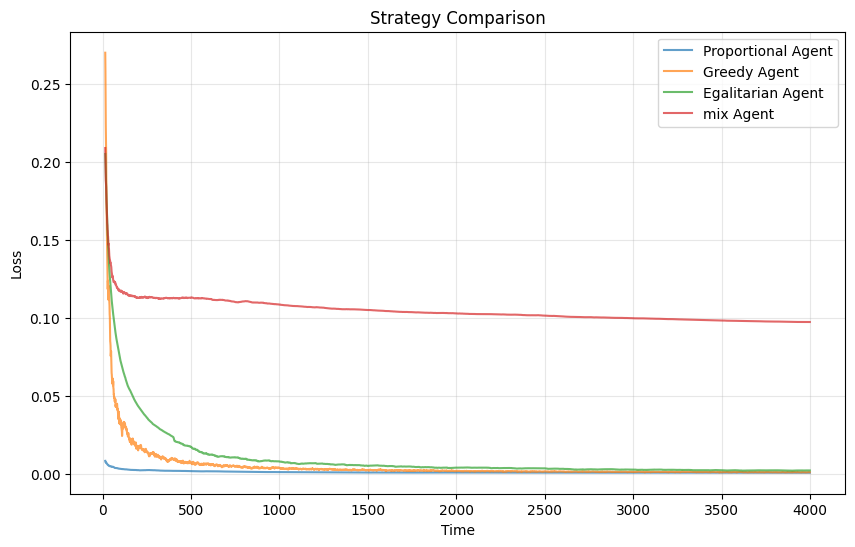

In [17]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))
# plt.plot(
#     time_steps, simulated_state_base[training_period:], label="Base Agent", alpha=0.7
# )
# plt.plot(
#     time_steps,
#     simulated_state_equal[training_period:],
#     label="Equal Division Agent",
#     alpha=0.7,
# )
plt.plot(
    time_steps,
    simulated_state_prop[training_period:],
    label="Proportional Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    simulated_state_greed[training_period:],
    label="Greedy Agent",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_state_egal[training_period:],
    label="Egalitarian Agent",
    alpha=0.7,
)

# plt.plot(
#     time_steps,
#     simulated_state_egal[training_period:],
#     label="Egalitarian Agent",
#     alpha=0.7,
# )

# plt.plot(
#     time_steps,
#     simulated_state_petty[training_period:],
#     label="Petty Agent",
#     alpha=0.7,
# )

plt.plot(
    time_steps,
    simulated_state_mix[training_period:],
    label="mix Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()